# **LAB.4**

In [82]:
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **TASK 1**

In [83]:
df.head()
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


np.int64(0)



After exploring the dataset using df.info(), df.describe(), and other functions, the following data quality issues were identified:

- The Age, Cabin, and Embarked columns contain missing values  
- The Cabin column has a large number of missing values  
- The Fare column may contain outliers

# **TASK 2**



To handle missing values:

- Age is filled with the median  
- Embarked is filled with the mode  
- Cabin is dropped due to excessive missing values  

The median is used for Age because it is more robust to outliers.

In [84]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin'], inplace=True)
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# **TASK 3**

In [85]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [86]:
print("shape before removing outliers", df.shape)
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]
print("shape after removing outliers", df.shape)

shape before removing outliers (891, 11)
shape after removing outliers (775, 11)


This step removes extreme values and makes the data more consistent.

# **TASK 4**

In [87]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [88]:
from sklearn.preprocessing import MinMaxScaler
cols = ['Age', 'Fare', 'SibSp', 'Parch']
minmax_scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[cols] = minmax_scaler.fit_transform(df[cols])

df_minmax.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,0.271174,0.2,0.0,A/5 21171,0.111538,S
2,3,1,3,"Heikkinen, Miss. Laina",female,0.321438,0.0,0.0,STON/O2. 3101282,0.121923,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.434531,0.2,0.0,113803,0.816923,S
4,5,0,3,"Allen, Mr. William Henry",male,0.434531,0.0,0.0,373450,0.123846,S
5,6,0,3,"Moran, Mr. James",male,0.346569,0.0,0.0,330877,0.130128,Q


In [89]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[num_cols] = standard_scaler.fit_transform(df[num_cols])

df_zscore.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,-1.711134,-0.716709,0.708528,"Braund, Mr. Owen Harris",male,-0.528321,0.625606,-0.433718,A/5 21171,-0.779117,S
2,-1.703440,1.395266,0.708528,"Heikkinen, Miss. Laina",female,-0.215182,-0.486423,-0.433718,STON/O2. 3101282,-0.729373,S
3,-1.699593,1.395266,-2.016580,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.489381,0.625606,-0.433718,113803,2.599828,S
4,-1.695746,-0.716709,0.708528,"Allen, Mr. William Henry",male,0.489381,-0.486423,-0.433718,373450,-0.720161,S
5,-1.691899,-0.716709,0.708528,"Moran, Mr. James",male,-0.058613,-0.486423,-0.433718,330877,-0.690071,Q


Min-Max scales values between 0 and 1, while Z-score standardizes the data with mean 0 and standard deviation 1.

# **TASK 5**

In [90]:
cols = ['Age', 'Fare', 'SibSp', 'Parch']
corr_matrix = df[cols].corr()
corr_matrix

,Age,Fare,SibSp,Parch
Age,1.000000,0.085716,-0.335000,-0.204181
Fare,0.085716,1.000000,0.370388,0.336844
SibSp,-0.335000,0.370388,1.000000,0.410182
Parch,-0.204181,0.336844,0.410182,1.000000


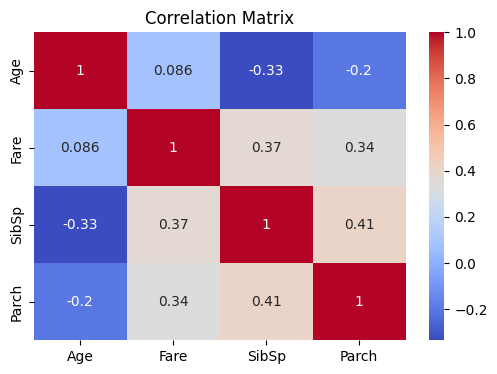

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

There is some correlation between the numerical features, so PCA can be applied.

In [92]:
from sklearn.decomposition import PCA

cols = ['Age', 'Fare', 'SibSp', 'Parch']

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_zscore[cols])

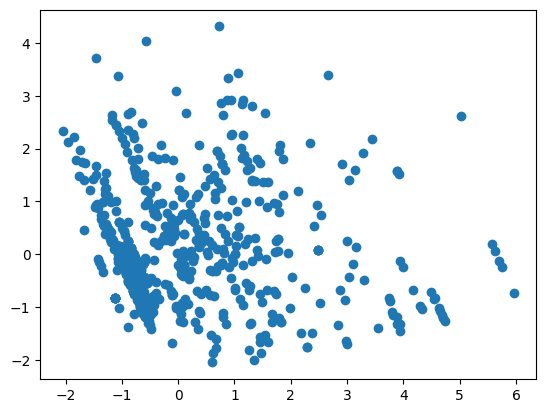

In [93]:
plt.scatter(pca_data[:,0], pca_data[:,1])
plt.show()